**Assigment 01**

Que 1.

In [16]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


# Create model
model = MLP()

# Test input
x = torch.tensor([[0.5]])

# Forward pass
u = model(x)

print("Input x =", x.item())
print("Output u(x) =", u.item())

Input x = 0.5
Output u(x) = 0.03913084417581558


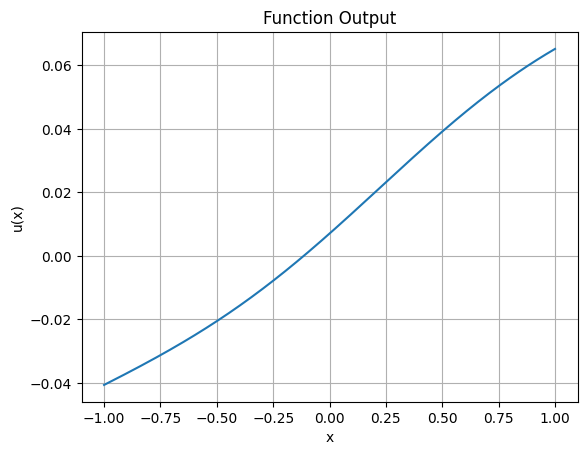

In [17]:
import numpy as np
import matplotlib.pyplot as plt

x = torch.linspace(-1, 1, 200).reshape(-1,1)

with torch.no_grad():
    y = model(x)

plt.plot(x.numpy(), y.numpy())
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Function Output")
plt.grid(True)
plt.show()

Que 2.

In [18]:
import torch
import torch.nn as nn

In [19]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [20]:
model = MLP()

In [21]:
x = torch.tensor([[0.5]], requires_grad=True)

In [22]:
u = model(x)

print("u(x) =", u.item())

u(x) = -0.15400268137454987


In [23]:
du_dx = torch.autograd.grad(
    outputs=u,
    inputs=x,
    grad_outputs=torch.ones_like(u),
    create_graph=True
)[0]

print("du/dx =", du_dx.item())

du/dx = -0.0025460422039031982


In [24]:
d2u_dx2 = torch.autograd.grad(
    outputs=du_dx,
    inputs=x,
    grad_outputs=torch.ones_like(du_dx),
    create_graph=True
)[0]

print("d²u/dx² =", d2u_dx2.item())

d²u/dx² = 0.1553899347782135


Que 3.

In [25]:
import torch
import numpy as np

x = -np.pi + 2*np.pi*torch.rand(100, 1)

x.requires_grad_(True)

tensor([[-2.9864],
        [ 0.5386],
        [-1.3632],
        [-3.1354],
        [ 2.2131],
        [ 0.3779],
        [-2.3760],
        [ 1.6307],
        [-1.0845],
        [-0.4580],
        [ 3.0116],
        [-0.8046],
        [-2.6545],
        [-1.8799],
        [-0.4967],
        [-0.8724],
        [ 2.0077],
        [-2.2619],
        [ 1.7973],
        [-1.2058],
        [ 1.2411],
        [-0.0655],
        [ 2.8789],
        [-1.5333],
        [-3.1212],
        [-0.1836],
        [ 2.9281],
        [-3.0620],
        [-2.5311],
        [-0.5156],
        [-1.8481],
        [-2.0886],
        [-1.9759],
        [-1.0881],
        [ 2.6988],
        [ 1.0608],
        [-1.0292],
        [ 1.4954],
        [ 3.1024],
        [ 1.2021],
        [ 1.0956],
        [-0.9006],
        [ 2.1264],
        [-0.0393],
        [-2.9806],
        [ 1.4521],
        [-2.2025],
        [ 0.3768],
        [-2.0816],
        [-2.1112],
        [ 1.8366],
        [-0.8831],
        [-0.

In [26]:
u = torch.sin(x)

du_dx = torch.autograd.grad(
    u,
    x,
    grad_outputs=torch.ones_like(u),
    create_graph=True
)[0]

d2u_dx2 = torch.autograd.grad(
    du_dx,
    x,
    grad_outputs=torch.ones_like(du_dx),
    create_graph=True
)[0]

In [27]:
du_dx_true = torch.cos(x)

d2u_dx2_true = -torch.sin(x)

Que 4.

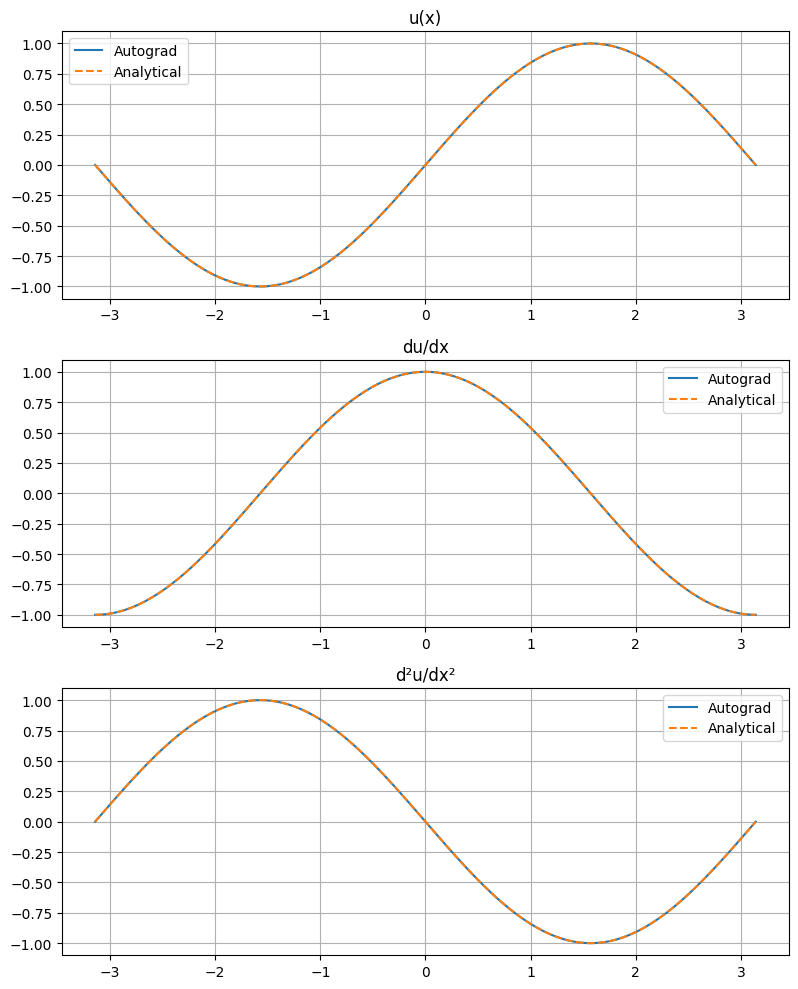

In [28]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Generate points
x = torch.linspace(-np.pi, np.pi, 200).reshape(-1,1)
x.requires_grad_(True)

# Function
u = torch.sin(x)

# Autograd derivatives
du_dx = torch.autograd.grad(
    u,
    x,
    grad_outputs=torch.ones_like(u),
    create_graph=True
)[0]

d2u_dx2 = torch.autograd.grad(
    du_dx,
    x,
    grad_outputs=torch.ones_like(du_dx),
    create_graph=True
)[0]

# Analytical derivatives
u_true = torch.sin(x)
du_dx_true = torch.cos(x)
d2u_dx2_true = -torch.sin(x)

# Convert to numpy for plotting
x_np = x.detach().numpy()

fig, axes = plt.subplots(3, 1, figsize=(8, 10))

# Plot 1
axes[0].plot(x_np, u.detach().numpy(), label="Autograd")
axes[0].plot(x_np, u_true.detach().numpy(), "--", label="Analytical")
axes[0].set_title("u(x)")
axes[0].legend()
axes[0].grid(True)

# Plot 2
axes[1].plot(x_np, du_dx.detach().numpy(), label="Autograd")
axes[1].plot(x_np, du_dx_true.detach().numpy(), "--", label="Analytical")
axes[1].set_title("du/dx")
axes[1].legend()
axes[1].grid(True)

# Plot 3
axes[2].plot(x_np, d2u_dx2.detach().numpy(), label="Autograd")
axes[2].plot(x_np, d2u_dx2_true.detach().numpy(), "--", label="Analytical")
axes[2].set_title("d²u/dx²")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Conclusion

PyTorch automatic differentiation was used to compute first and second derivatives. The derivatives obtained through autograd matched the analytical derivatives of sin(x), demonstrating the correctness of automatic differentiation.